# IN718 4×4 OCRP anchorless — active-convention right-invariance and left-SO(3)-equivariance proof

This notebook checks the trained **IN718 4×4 OCRP anchorless epoch-24** module layer by layer.

The claim being tested is deliberately side-specific:

$$
\boxed{\text{right crystal symmetry: } q \mapsto q \otimes h,\ h\in O \quad\Rightarrow\quad \text{invariance}}
$$

$$
\boxed{\text{left global rotation: } q \mapsto g \otimes q,\ g\in SO(3) \quad\Rightarrow\quad \text{SO(3)-equivariance}}
$$

and **not vice versa**.

In active convention, the orientation quaternion maps a crystal-frame vector into the sample/lab frame. Therefore:

- multiplying on the **right** changes only the crystal-basis representative: same physical orientation class;
- multiplying on the **left** rotates the entire physical orientation in the sample/lab frame.

So the correct quotient/equivariance behavior is:

$$
F(q \otimes h)=F(q), \qquad h\in O,
$$

and for irrep-valued feature tensors,

$$
F(g\otimes q)=D(g)F(q).
$$

Because tensors are stored as row vectors in this code, the notebook applies the row-vector version:

$$
F(g\otimes q)_{\mathrm{row}} = F(q)_{\mathrm{row}}D(g)^\mathsf{T}.
$$

The checks below use the real Open718 paper-side test HR field, a derived 4× LR grid, and the real epoch-24 checkpoint.
        


## Exact source locations used in this proof

This notebook is not proving a toy model. It calls the same production source modules used by the trained OCRP checkpoint.

| What is being checked | Exact source lines |
| --- | --- |
| Experiment says this is 4×4 FCC/O(h), full irreps, 9×9 window, 6 slots, 2° clustering | [config_new.json:16](/data/home/umang/Materials/Reynolds-QSR_paper/experiments/IN718/iso_embedding_4x4_ocrp_anchorless_4x1clone_01/config_new.json:16), lines 16-37 |
| Experiment selects `models.SR_4x4_from_4x1_ocrp_anchorless.IsoEmbedding4x4FromSROCRP`; this notebook overrides the old config `viz_sample_key = x_230` with `Open_718_Test_hr_x_block_0.npy` for the real-data proof crop | [config_new.json:95](/data/home/umang/Materials/Reynolds-QSR_paper/experiments/IN718/iso_embedding_4x4_ocrp_anchorless_4x1clone_01/config_new.json:95), lines 95-100 |
| 4×4 wrapper fixes `upsample_factor=(4, 4)` | [SR_4x4_from_4x1_ocrp_anchorless.py:2215](/data/home/umang/Materials/Reynolds-QSR_paper/models/SR_4x4_from_4x1_ocrp_anchorless.py:2215), lines 2215-2219 |
| Model builds local-iso encoder | [SR_4x4_from_4x1_ocrp_anchorless.py:1785](/data/home/umang/Materials/Reynolds-QSR_paper/models/SR_4x4_from_4x1_ocrp_anchorless.py:1785), lines 1785-1790 |
| Model builds LR conv, OCRP, HR conv1, HR conv2 | [SR_4x4_from_4x1_ocrp_anchorless.py:1870](/data/home/umang/Materials/Reynolds-QSR_paper/models/SR_4x4_from_4x1_ocrp_anchorless.py:1870), lines 1870-1936 |
| Public encoder dispatches to full local-iso irreps | [SR_4x4_from_4x1_ocrp_anchorless.py:2016](/data/home/umang/Materials/Reynolds-QSR_paper/models/SR_4x4_from_4x1_ocrp_anchorless.py:2016), lines 2016-2019 |
| Wrapper passes API quaternions into `forward_irreps_passive` | [SR_4x4_from_4x1_ocrp_anchorless.py:490](/data/home/umang/Materials/Reynolds-QSR_paper/models/SR_4x4_from_4x1_ocrp_anchorless.py:490), lines 490-492 |
| Local-iso source converts passive input to active internally | [local_iso_embedding.py:635](/data/home/umang/Materials/Reynolds-QSR_paper/models/local_iso_embedding.py:635), lines 635-649 |
| Local-iso source builds active rotation matrices | [local_iso_embedding.py:24](/data/home/umang/Materials/Reynolds-QSR_paper/models/local_iso_embedding.py:24), lines 24-59 |
| Local-iso source performs orbit averaging and irrep projection | [local_iso_embedding.py:586](/data/home/umang/Materials/Reynolds-QSR_paper/models/local_iso_embedding.py:586), lines 586-617 |
| Feature SR path applies LR conv → OCRP → HR convs and returns probes | [SR_4x4_from_4x1_ocrp_anchorless.py:2031](/data/home/umang/Materials/Reynolds-QSR_paper/models/SR_4x4_from_4x1_ocrp_anchorless.py:2031), lines 2031-2086 |
| Cosine-masked equivariant convolution | [SR_4x4_from_4x1_ocrp_anchorless.py:315](/data/home/umang/Materials/Reynolds-QSR_paper/models/SR_4x4_from_4x1_ocrp_anchorless.py:315), lines 315-441 |
| OCRP forward: bank → cluster → slots → router → cross-attention → HR assembly | [SR_4x4_from_4x1_ocrp_anchorless.py:1584](/data/home/umang/Materials/Reynolds-QSR_paper/models/SR_4x4_from_4x1_ocrp_anchorless.py:1584), lines 1584-1698 |
| Quaternion clusterer uses symmetry-aware misorientation edges | [SR_4x4_from_4x1_ocrp_anchorless.py:800](/data/home/umang/Materials/Reynolds-QSR_paper/models/SR_4x4_from_4x1_ocrp_anchorless.py:800), lines 800-819 |
| Cluster slot builder emits scalar slot masks/metadata | [SR_4x4_from_4x1_ocrp_anchorless.py:852](/data/home/umang/Materials/Reynolds-QSR_paper/models/SR_4x4_from_4x1_ocrp_anchorless.py:852), lines 852-1008 |
| Patch router maps scalar slot masks + phase to scalar logits | [SR_4x4_from_4x1_ocrp_anchorless.py:1037](/data/home/umang/Materials/Reynolds-QSR_paper/models/SR_4x4_from_4x1_ocrp_anchorless.py:1037), lines 1037-1166 |
| Anchorless member cross-attention uses invariant summaries for weights and weighted sums of equivariant features | [SR_4x4_from_4x1_ocrp_anchorless.py:1225](/data/home/umang/Materials/Reynolds-QSR_paper/models/SR_4x4_from_4x1_ocrp_anchorless.py:1225), lines 1225-1333 |
        


## Why the side matters

Let \(R(q)\) be the active rotation matrix represented by the active quaternion \(q\).

For active quaternions:

$$
R(g\otimes q)=R(g)R(q),
\qquad
R(q\otimes h)=R(q)R(h).
$$

The local-iso encoder averages tensor powers over a crystal orbit:

$$
T(R)=\frac{1}{|O|}\sum_{u\in O\cdot u_0}(Ru)^{\otimes k}.
$$

Right multiplication by \(h\in O\) gives:

$$
T(RR(h))
=
\frac{1}{|O|}\sum_{u\in O\cdot u_0}(RR(h)u)^{\otimes k}.
$$

Because \(h\) is a crystal symmetry, \(R(h)\) only permutes the orbit \(O\cdot u_0\). The average is unchanged:

$$
T(RR(h))=T(R).
$$

Left multiplication by \(g\in SO(3)\) gives:

$$
T(R(g)R)=D(g)T(R),
$$

after projection to the irreducible representation channels.

That is the root of the whole notebook:

- **right by crystal group** = same quotient representative = invariant;
- **left by any SO(3) rotation** = physical rotation of the lab-frame tensor = equivariant.
        

In [1]:
from __future__ import annotations

import inspect
import importlib
import json
import math
import sys
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import torch

try:
    from e3nn.o3 import Irreps
except ModuleNotFoundError as exc:
    raise ModuleNotFoundError(
        "This notebook must be run in the project environment with e3nn installed. "
        "On this machine, use /data/home/umang/miniconda3/envs/material/bin/python "
        "or the matching Jupyter kernel."
    ) from exc

warnings.filterwarnings("ignore", category=FutureWarning)

ROOT = Path("/data/home/umang/Materials/Reynolds-QSR_paper")
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

CONFIG_PATH = ROOT / "experiments/IN718/iso_embedding_4x4_ocrp_anchorless_4x1clone_01/config_new.json"
CHECKPOINT_PATH = ROOT / "experiments/IN718/iso_embedding_4x4_ocrp_anchorless_4x1clone_01/checkpoints/epoch_0024.pt"
HR_SAMPLE_PATH = ROOT / "Paper" / "EBSD_SR_Nature_v3" / "Open_718_Test_hr_x_block_0.npy"
SAMPLE_ID = "Open_718_Test_hr_x_block_0"
SCALE_YX = (4, 4)

OUT_DIR = ROOT / "analysis/out/ocrp_4x4_active_symmetry_layer_proof"
OUT_DIR.mkdir(parents=True, exist_ok=True)

DEVICE = torch.device("cpu")
DTYPE = torch.float32
LR_R0, LR_C0 = 20, 26
LR_CROP_SIZE = 4

print("config:", CONFIG_PATH)
print("checkpoint:", CHECKPOINT_PATH)
print("sample HR source:", HR_SAMPLE_PATH)
print("sample LR source: derived from HR by stride-4 sampling")
print("out:", OUT_DIR)


config: /data/home/umang/Materials/Reynolds-QSR_paper/experiments/IN718/iso_embedding_4x4_ocrp_anchorless_4x1clone_01/config_new.json
checkpoint: /data/home/umang/Materials/Reynolds-QSR_paper/experiments/IN718/iso_embedding_4x4_ocrp_anchorless_4x1clone_01/checkpoints/epoch_0024.pt
sample HR source: /data/home/umang/Materials/Reynolds-QSR_paper/Paper/EBSD_SR_Nature_v3/Open_718_Test_hr_x_block_0.npy
sample LR source: derived from HR by stride-4 sampling
out: /data/home/umang/Materials/Reynolds-QSR_paper/analysis/out/ocrp_4x4_active_symmetry_layer_proof


In [2]:
def qnormalize_torch(q: torch.Tensor, eps: float = 1e-12) -> torch.Tensor:
    q = q / q.norm(dim=-1, keepdim=True).clamp_min(eps)
    return torch.where(q[..., :1] < 0.0, -q, q)


def qconj_torch(q: torch.Tensor) -> torch.Tensor:
    return torch.cat([q[..., :1], -q[..., 1:]], dim=-1)


def qmul_torch(a: torch.Tensor, b: torch.Tensor) -> torch.Tensor:
    # Hamilton product a ⊗ b for scalar-first [w,x,y,z] quaternions.
    aw, ax, ay, az = a.unbind(dim=-1)
    bw, bx, by, bz = b.unbind(dim=-1)
    out = torch.stack(
        [
            aw * bw - ax * bx - ay * by - az * bz,
            aw * bx + ax * bw + ay * bz - az * by,
            aw * by - ax * bz + ay * bw + az * bx,
            aw * bz + ax * by - ay * bx + az * bw,
        ],
        dim=-1,
    )
    return qnormalize_torch(out)


def quat_to_matrix_active_torch(q: torch.Tensor) -> torch.Tensor:
    # Same active scalar-first quaternion-to-matrix formula used by local_iso_embedding.py:24-59.
    q = qnormalize_torch(q)
    w, x, y, z = q.unbind(dim=-1)
    ww, xx, yy, zz = w * w, x * x, y * y, z * z
    wx, wy, wz = w * x, w * y, w * z
    xy, xz, yz = x * y, x * z, y * z
    R = torch.stack(
        [
            1.0 - 2.0 * (yy + zz),
            2.0 * (xy - wz),
            2.0 * (xz + wy),
            2.0 * (xy + wz),
            1.0 - 2.0 * (xx + zz),
            2.0 * (yz - wx),
            2.0 * (xz - wy),
            2.0 * (yz + wx),
            1.0 - 2.0 * (xx + yy),
        ],
        dim=-1,
    )
    return R.reshape(*q.shape[:-1], 3, 3)


def qnormalize_np(q: np.ndarray, eps: float = 1e-12) -> np.ndarray:
    q = np.asarray(q, dtype=np.float32)
    q = q / np.maximum(np.linalg.norm(q, axis=-1, keepdims=True), eps)
    return np.where(q[..., :1] < 0.0, -q, q).astype(np.float32)


def qconj_np(q: np.ndarray) -> np.ndarray:
    out = np.array(q, dtype=np.float32, copy=True)
    out[..., 1:] *= -1.0
    return out


def xyzw_to_wxyz_np(q_xyzw: np.ndarray) -> np.ndarray:
    q = np.asarray(q_xyzw, dtype=np.float32)
    if q.shape[-1] != 4:
        raise ValueError(f"expected quaternion-last array, got {q.shape}")
    return np.concatenate([q[..., 3:4], q[..., :3]], axis=-1).astype(np.float32)


def infer_scalar_layout_np(q_raw: np.ndarray, *, ratio_threshold: float = 1.5) -> str:
    q = np.asarray(q_raw, dtype=np.float32)
    if q.shape[-1] != 4:
        raise ValueError(f"expected quaternion-last array, got {q.shape}")
    abs_mean = np.mean(np.abs(q.reshape(-1, 4)), axis=0)
    first, last = float(abs_mean[0]), float(abs_mean[-1])
    if first > ratio_threshold * max(last, 1e-12):
        return "wxyz"
    if last > ratio_threshold * max(first, 1e-12):
        return "xyzw"
    raise ValueError(
        "Cannot confidently infer scalar position from component magnitudes: "
        f"abs_mean={abs_mean}. Set the scalar layout explicitly."
    )


def raw_to_passive_wxyz_np(q_raw: np.ndarray, scalar_layout: str = "auto") -> tuple[np.ndarray, str, np.ndarray]:
    q = np.asarray(q_raw, dtype=np.float32)
    layout = infer_scalar_layout_np(q) if scalar_layout == "auto" else str(scalar_layout).lower()
    abs_mean = np.mean(np.abs(q.reshape(-1, 4)), axis=0)
    if layout == "xyzw":
        q_passive = xyzw_to_wxyz_np(q)
    elif layout == "wxyz":
        q_passive = q.astype(np.float32, copy=True)
    else:
        raise ValueError(f"scalar_layout must be 'auto', 'xyzw', or 'wxyz', got {scalar_layout!r}")
    return qnormalize_np(q_passive), layout, abs_mean


def passive_to_active_np(q_passive_wxyz: np.ndarray) -> np.ndarray:
    return qnormalize_np(qconj_np(q_passive_wxyz))


def to_hwc_quat_np(arr: np.ndarray) -> np.ndarray:
    arr = np.asarray(arr)
    if arr.ndim != 3:
        raise ValueError(f"expected rank-3 quaternion image, got {arr.shape}")
    if arr.shape[-1] == 4:
        return arr
    if arr.shape[0] == 4:
        return np.moveaxis(arr, 0, -1)
    raise ValueError(f"cannot identify quaternion axis in shape {arr.shape}")


def checkpoint_input_from_active(q_active: torch.Tensor) -> torch.Tensor:
    # Notebook adapter: active display convention -> unchanged checkpoint API convention.
    return qnormalize_torch(qconj_torch(q_active))


def checkpoint_output_to_active(q_api: torch.Tensor) -> torch.Tensor:
    return qnormalize_torch(qconj_torch(q_api))


def right_crystal_action_active(q_active: torch.Tensor, h_active: torch.Tensor) -> torch.Tensor:
    # Active right crystal action: q -> q ⊗ h.
    return qmul_torch(q_active, h_active)


def left_so3_action_active(g_active: torch.Tensor, q_active: torch.Tensor) -> torch.Tensor:
    # Active left SO(3) action: q -> g ⊗ q.
    return qmul_torch(g_active, q_active)


def apply_feature_action_row(t: torch.Tensor, A_row: torch.Tensor) -> torch.Tensor:
    # Apply row-vector irrep action to the last feature dimension.
    return torch.einsum("...c,cd->...d", t, A_row)
        


## Load the real epoch-24 model and Open718-derived LR crop

The Open718 paper-side `.npy` file is scalar-last. The scalar position is directly checked from the component magnitudes. The active/passive side is not identifiable from a normalized quaternion array alone; here it is fixed by the OCRP source/API and repo EBSD convention, which treat stored EBSD quaternions as passive and conjugate them internally for active rotation matrices.

So this file is used as passive scalar-last:

$$
q_{\mathrm{raw}}=[x,y,z,w].
$$

The checkpoint API expects passive scalar-first:

$$
q_{\mathrm{passive}}=[w,x,y,z].
$$

This proof notebook displays and manipulates active quaternions only after that reorder, then uses:

$$
q_{\mathrm{api}} = q_{\mathrm{active}}^*
$$

at the model boundary.

There is no IPF rendering in this proof notebook. If an IPF-Z view is added later, it should use the passive scalar-first tensor `q_passive=[w,x,y,z]`, not the active-conjugated proof tensor. The active tensor is for the right-invariance / left-equivariance checks only.

That is consistent with the source because `forward_irreps_passive` immediately computes:

$$
q_{\mathrm{active}} = q_{\mathrm{passive}}^*
$$

at [local_iso_embedding.py:647](/data/home/umang/Materials/Reynolds-QSR_paper/models/local_iso_embedding.py:647), and then builds the active rotation matrix at [local_iso_embedding.py:648](/data/home/umang/Materials/Reynolds-QSR_paper/models/local_iso_embedding.py:648).
        


In [3]:
def build_model_from_config(config_path: Path, checkpoint_path: Path, device: torch.device):
    cfg = json.loads(config_path.read_text())
    model_cfg = cfg["model"]
    module = importlib.import_module(model_cfg["model_module"])
    cls = getattr(module, model_cfg["model_class"])

    sig = inspect.signature(cls)
    kwargs = {k: v for k, v in cfg.items() if k in sig.parameters}
    kwargs["device"] = device
    kwargs["decoder_eager_init"] = False

    model = cls(**kwargs).to(device).eval()
    ckpt = torch.load(checkpoint_path, map_location=device)
    state = ckpt.get("model_state_dict", ckpt)
    load_result = model.load_state_dict(state, strict=True)
    return cfg, ckpt, model, load_result


cfg, ckpt, model, load_result = build_model_from_config(CONFIG_PATH, CHECKPOINT_PATH, DEVICE)
scale_y, scale_x = SCALE_YX
hr_raw = to_hwc_quat_np(np.load(HR_SAMPLE_PATH)).astype(np.float32, copy=False)
hr_passive_raw, RAW_SCALAR_LAYOUT, RAW_COMPONENT_ABS_MEAN = raw_to_passive_wxyz_np(hr_raw, scalar_layout="auto")
RAW_QUATERNION_CONVENTION = "passive"
hr_h_aligned = (hr_passive_raw.shape[0] // scale_y) * scale_y
hr_w_aligned = (hr_passive_raw.shape[1] // scale_x) * scale_x
hr_passive = hr_passive_raw[:hr_h_aligned, :hr_w_aligned].copy()
lr_passive = hr_passive[::scale_y, ::scale_x].copy()
lr_active = passive_to_active_np(lr_passive)

lr_crop_active_np = lr_active[
    LR_R0 : LR_R0 + LR_CROP_SIZE,
    LR_C0 : LR_C0 + LR_CROP_SIZE,
]
lr_crop_active = torch.from_numpy(lr_crop_active_np).to(device=DEVICE, dtype=DTYPE)
lr_shape = (LR_CROP_SIZE, LR_CROP_SIZE)
num_lr_tokens = LR_CROP_SIZE * LR_CROP_SIZE

print("checkpoint saved epoch field:", ckpt.get("epoch"), "(file is epoch_0024.pt)")
print("load result:", load_result)
print("model class:", model.__class__.__name__)
print("feature_irreps:", model.feature_irreps)
print("irreps_feat:", model.irreps_feat)
print("feature_dim:", model.feature_dim)
print("upsample_factor:", model.upsample_factor)
print("OCRP window_size:", model.ocrp.window_size)
print("OCRP kmax_slots:", model.ocrp.kmax_slots)
print("HR raw/aligned:", tuple(hr_raw.shape), "->", tuple(hr_passive.shape))
print("raw component |mean|:", RAW_COMPONENT_ABS_MEAN)
print("detected raw scalar layout:", RAW_SCALAR_LAYOUT, "([x,y,z,w] if xyzw)")
print("raw quaternion convention:", RAW_QUATERNION_CONVENTION)
print("checkpoint API layout after conversion: passive_wxyz")
print("derived LR active shape:", tuple(lr_active.shape), "from", SAMPLE_ID)
print("LR crop active shape:", tuple(lr_crop_active.shape), "global top-left:", (LR_R0, LR_C0))


checkpoint saved epoch field: 23 (file is epoch_0024.pt)
load result: <All keys matched successfully>
model class: IsoEmbedding4x4FromSROCRP
feature_irreps: full
irreps_feat: 1x2e+1x4e
feature_dim: 14
upsample_factor: (4, 4)
OCRP window_size: 9
OCRP kmax_slots: 6
HR raw/aligned: (301, 390, 4) -> (300, 388, 4)
raw component |mean|: [0.18778956 0.18947135 0.14824016 0.93412596]
detected raw scalar layout: xyzw ([x,y,z,w] if xyzw)
raw quaternion convention: passive
checkpoint API layout after conversion: passive_wxyz
derived LR active shape: (75, 97, 4) from Open_718_Test_hr_x_block_0
LR crop active shape: (4, 4, 4) global top-left: (20, 26)


## Build the two active-convention probes

We build three branches:

1. `base`: original active crop \(q\);
2. `right`: independently apply random cubic crystal symmetries at each LR pixel:

   $$
   q_i \mapsto q_i\otimes h_i,\qquad h_i\in O;
   $$

   this is a strong right-invariance test because every pixel can choose a different crystal representative.

3. `left`: apply one generic non-cubic SO(3) rotation to the whole crop:

   $$
   q_i \mapsto g\otimes q_i,\qquad g\in SO(3).
   $$

For left equivariance, the row-vector feature action is:

$$
A_{\mathrm{row}}(g)=D_{\mathrm{e3nn}}(R(g))^\mathsf{T}.
$$

The notebook verifies that \(A_{\mathrm{row}}\) is orthogonal and then uses it for every irrep-valued layer.
        

In [4]:
sym_ops_active = model.encoder.sym_ops.detach().to(device=DEVICE, dtype=DTYPE)

# Independent right crystal representative per LR pixel.
gen = torch.Generator(device="cpu")
gen.manual_seed(123)
sym_idx = torch.randint(0, sym_ops_active.shape[0], (num_lr_tokens,), generator=gen)
h_per_pixel = sym_ops_active[sym_idx].reshape(LR_CROP_SIZE, LR_CROP_SIZE, 4)
lr_crop_right_active = right_crystal_action_active(lr_crop_active, h_per_pixel)

# One fixed generic SO(3) probe, intentionally not one of the cubic symmetries.
g_left = qnormalize_torch(torch.tensor([0.913, 0.143, 0.287, 0.258], dtype=DTYPE, device=DEVICE).view(1, 4))[0]
lr_crop_left_active = left_so3_action_active(g_left.view(1, 1, 4).expand_as(lr_crop_active), lr_crop_active)

irreps_feat = Irreps(model.irreps_feat)
D_col = irreps_feat.D_from_matrix(quat_to_matrix_active_torch(g_left).detach().cpu()).to(device=DEVICE, dtype=DTYPE)
A_left_row = D_col.T.contiguous()
orth_err = float((A_left_row.T @ A_left_row - torch.eye(A_left_row.shape[0], device=DEVICE, dtype=DTYPE)).abs().max())

print("symmetry ops:", tuple(sym_ops_active.shape))
print("right branch uses per-token sym op indices:", sym_idx.reshape(LR_CROP_SIZE, LR_CROP_SIZE).tolist())
print("left SO(3) probe:", g_left.tolist())
print("row action matrix shape:", tuple(A_left_row.shape))
print("row action orthogonality max error:", f"{orth_err:.3e}")
        

symmetry ops: (24, 4)
right branch uses per-token sym op indices: [[22, 13, 6, 18], [4, 2, 6, 17], [11, 10, 11, 1], [6, 1, 16, 9]]
left SO(3) probe: [0.911655843257904, 0.14278948307037354, 0.2865774631500244, 0.2576201558113098]
row action matrix shape: (14, 14)
row action orthogonality max error: 4.172e-06


## Run the real OCRP feature pipeline

This function is intentionally thin. It only:

1. converts active notebook quaternions to the unchanged checkpoint API convention;
2. calls `model.encode(...)`;
3. calls `model._forward_sr_features(..., return_aux=True)`.

The layer tensors are produced by source code at:

- `model.encode`: [SR_4x4_from_4x1_ocrp_anchorless.py:2016](/data/home/umang/Materials/Reynolds-QSR_paper/models/SR_4x4_from_4x1_ocrp_anchorless.py:2016), lines 2016-2019;
- `_forward_sr_features`: [SR_4x4_from_4x1_ocrp_anchorless.py:2031](/data/home/umang/Materials/Reynolds-QSR_paper/models/SR_4x4_from_4x1_ocrp_anchorless.py:2031), lines 2031-2086;
- OCRP aux tensors: [SR_4x4_from_4x1_ocrp_anchorless.py:1661](/data/home/umang/Materials/Reynolds-QSR_paper/models/SR_4x4_from_4x1_ocrp_anchorless.py:1661), lines 1661-1692.
        

In [5]:
def run_feature_pipeline_from_active(q_active_grid: torch.Tensor):
    q_active_flat = q_active_grid.reshape(-1, 4)
    q_api_flat = checkpoint_input_from_active(q_active_flat)
    with torch.no_grad():
        feat_lr_flat = model.encode(q_api_flat)
        feat_lr = feat_lr_flat.reshape(1, -1, feat_lr_flat.shape[-1])
        feat_hr, hr_shape_out, aux = model._forward_sr_features(
            lr_quats=q_api_flat.reshape(1, -1, 4),
            feat_lr=feat_lr,
            lr_shape=lr_shape,
            return_aux=True,
        )
    tensors = {
        "feat_lr_encode": feat_lr,
        **aux,
        "feat_hr_final": feat_hr,
    }
    return tensors, hr_shape_out


base, hr_shape = run_feature_pipeline_from_active(lr_crop_active)
right, hr_shape_right = run_feature_pipeline_from_active(lr_crop_right_active)
left, hr_shape_left = run_feature_pipeline_from_active(lr_crop_left_active)

assert hr_shape == hr_shape_right == hr_shape_left
print("HR shape:", hr_shape)
print("available tensors:")
for k in sorted(base):
    v = base[k]
    if isinstance(v, torch.Tensor):
        print(f"  {k:26s} {tuple(v.shape)} {v.dtype}")
    elif k == "probe_stages":
        print(f"  {k:26s} list length={len(v)}")
        for stage in v:
            feat = stage.get("feat")
            shape = tuple(feat.shape) if isinstance(feat, torch.Tensor) else None
            print(f"    - {stage.get('name')}: feat={shape}, image_shape={stage.get('shape')}")
    else:
        print(f"  {k:26s} {type(v).__name__}: {v}")
        

HR shape: (16, 16)
available tensors:
  bank_f                     (1, 16, 81, 14) torch.float32
  bank_q                     (1, 16, 81, 4) torch.float32
  cluster_ids                (1, 16, 81) torch.int64
  feat_hr_final              (1, 256, 14) torch.float32
  feat_hr_post_hr_conv       (1, 256, 14) torch.float32
  feat_hr_post_hr_conv1      (1, 256, 14) torch.float32
  feat_hr_post_hr_conv2      (1, 256, 14) torch.float32
  feat_hr_raw_ocrp           (1, 256, 14) torch.float32
  feat_lr_encode             (1, 16, 14) torch.float32
  feat_lr_pre_ocrp           (1, 16, 14) torch.float32
  hr_patch_shape             tuple: (4, 4)
  hr_patch_size              int: 4
  hr_patch_tokens            int: 16
  lr_padded_shape            tuple: (4, 4)
  macro_lr_stride_shape      tuple: (1, 4)
  macro_lr_tile_size         tuple: (1, 4)
  ocrp_mode                  str: pixel_patch
  owner_idx                  (1, 16, 16) torch.int64
  patch_out                  (1, 16, 16, 14) torch.float32

## Metrics used in the layerwise proof

For an irrep-valued feature tensor \(X\), the checks are:

Right crystal invariance:

$$
\mathrm{err}_{\mathrm{right}}=\|X(q\otimes h)-X(q)\|.
$$

Left SO(3) equivariance:

$$
\mathrm{err}_{\mathrm{left}}=\|X(g\otimes q)-X(q)A_{\mathrm{row}}(g)\|.
$$

Wrong-side control:

$$
\mathrm{err}_{\mathrm{left\ as\ invariant}}=\|X(g\otimes q)-X(q)\|.
$$

That last number should be large for non-scalar irrep features. It proves we are not accidentally treating left SO(3) as an invariance.

For scalar routing quantities such as `cluster_ids`, `slot_mask`, `slot_meta`, `router_logits`, and `owner_idx`, there is no irrep channel action. They are type-0 quantities, so they should be invariant under both the right crystal representative change and the common left frame rotation. This does not violate the main claim: those scalar quantities only choose/weight equivariant feature vectors.

One nuance: `xattn_alpha` is a returned diagnostic softmax tensor from the attention path. It is scalar, but it is not expected to be bit-exact because tiny floating-point differences in nearly tied scores can move softmax weights slightly. The important functional check is that the scalar-weighted feature outputs `patch_prop`, `patch_out`, and the final HR feature tensor still satisfy the symmetry relations.
        

In [6]:
def tensor_error(expected: torch.Tensor, observed: torch.Tensor) -> dict:
    if expected.dtype == torch.bool or observed.dtype == torch.bool:
        eq = expected == observed
        return {
            "kind": "exact/bool",
            "rel": np.nan,
            "rms": float((expected.float() - observed.float()).square().mean().sqrt()),
            "max_abs": float((expected.float() - observed.float()).abs().max()),
            "exact": bool(eq.all()),
            "neq_frac": float((~eq).float().mean()),
        }
    if not torch.is_floating_point(expected) or not torch.is_floating_point(observed):
        eq = expected == observed
        return {
            "kind": "exact/int",
            "rel": np.nan,
            "rms": float((expected.float() - observed.float()).square().mean().sqrt()),
            "max_abs": float((expected.float() - observed.float()).abs().max()),
            "exact": bool(eq.all()),
            "neq_frac": float((~eq).float().mean()),
        }
    diff = (expected - observed).detach().float()
    rel = float(diff.norm().item() / (observed.detach().float().norm().item() + 1e-12))
    return {
        "kind": "float",
        "rel": rel,
        "rms": float(diff.square().mean().sqrt()),
        "max_abs": float(diff.abs().max()),
        "exact": bool(diff.abs().max() == 0),
        "neq_frac": np.nan,
    }


feature_tensors = [
    "feat_lr_encode",
    "feat_lr_pre_ocrp",
    "bank_f",
    "patch_prop",
    "patch_out",
    "feat_hr_raw_ocrp",
    "feat_hr_post_hr_conv1",
    "feat_hr_post_hr_conv2",
    "feat_hr_post_hr_conv",
    "feat_hr_final",
]

scalar_tensors = [
    "cluster_ids",
    "slot_mask",
    "slot_valid",
    "slot_meta",
    "router_logits",
    "owner_idx",
    "xattn_alpha",
]

rows = []
for name in feature_tensors:
    if name not in base or base[name] is None:
        continue
    right_err = tensor_error(base[name], right[name])
    left_eq_err = tensor_error(apply_feature_action_row(base[name], A_left_row), left[name])
    left_inv_wrong = tensor_error(base[name], left[name])
    rows.append(
        {
            "tensor": name,
            "tensor_type": "irrep feature",
            "shape": tuple(base[name].shape),
            "right_crystal_should_be": "invariant",
            "right_rel": right_err["rel"],
            "right_rms": right_err["rms"],
            "right_max_abs": right_err["max_abs"],
            "left_SO3_should_be": "equivariant",
            "left_eq_rel": left_eq_err["rel"],
            "left_eq_rms": left_eq_err["rms"],
            "left_eq_max_abs": left_eq_err["max_abs"],
            "wrong_left_as_invariant_rel": left_inv_wrong["rel"],
            "wrong_left_as_invariant_rms": left_inv_wrong["rms"],
            "exact": np.nan,
            "neq_frac": np.nan,
        }
    )

for name in scalar_tensors:
    if name not in base or base[name] is None:
        continue
    right_err = tensor_error(base[name], right[name])
    left_inv_err = tensor_error(base[name], left[name])
    rows.append(
        {
            "tensor": name,
            "tensor_type": "scalar routing/index",
            "shape": tuple(base[name].shape),
            "right_crystal_should_be": "invariant",
            "right_rel": right_err["rel"],
            "right_rms": right_err["rms"],
            "right_max_abs": right_err["max_abs"],
            "left_SO3_should_be": "scalar invariant",
            "left_eq_rel": left_inv_err["rel"],
            "left_eq_rms": left_inv_err["rms"],
            "left_eq_max_abs": left_inv_err["max_abs"],
            "wrong_left_as_invariant_rel": np.nan,
            "wrong_left_as_invariant_rms": np.nan,
            "exact": left_inv_err["exact"] and right_err["exact"],
            "neq_frac": max(
                0.0 if np.isnan(right_err["neq_frac"]) else right_err["neq_frac"],
                0.0 if np.isnan(left_inv_err["neq_frac"]) else left_inv_err["neq_frac"],
            ),
        }
    )

df = pd.DataFrame(rows)
csv_path = OUT_DIR / "layerwise_right_invariant_left_equivariant_checks.csv"
df.to_csv(csv_path, index=False)
print("saved:", csv_path)
display(
    df[
        [
            "tensor",
            "tensor_type",
            "shape",
            "right_rel",
            "right_max_abs",
            "left_eq_rel",
            "left_eq_max_abs",
            "wrong_left_as_invariant_rel",
            "exact",
        ]
    ]
)
        

saved: /data/home/umang/Materials/Reynolds-QSR_paper/analysis/out/ocrp_4x4_active_symmetry_layer_proof/layerwise_right_invariant_left_equivariant_checks.csv


,tensor,tensor_type,shape,right_rel,right_max_abs,left_eq_rel,left_eq_max_abs,wrong_left_as_invariant_rel,exact
0,feat_lr_encode,irrep feature,"(1, 16, 14)",7.427838e-07,2.086163e-07,0.000003,0.000001,1.566484,NaN
1,feat_lr_pre_ocrp,irrep feature,"(1, 16, 14)",8.632713e-07,3.576279e-07,0.000003,0.000002,1.566487,NaN
2,bank_f,irrep feature,"(1, 16, 81, 14)",7.514100e-07,3.576279e-07,0.000003,0.000002,1.542307,NaN
3,patch_prop,irrep feature,"(1, 16, 6, 16, 14)",5.196482e-06,9.655952e-06,0.000005,0.000009,1.491496,NaN
4,patch_out,irrep feature,"(1, 16, 16, 14)",8.343129e-06,9.655952e-06,0.000007,0.000009,1.567527,NaN
5,feat_hr_raw_ocrp,irrep feature,"(1, 256, 14)",8.343129e-06,9.655952e-06,0.000007,0.000009,1.567527,NaN
6,feat_hr_post_hr_conv1,irrep feature,"(1, 256, 14)",7.651087e-06,6.467104e-06,0.000007,0.000006,1.567513,NaN
7,feat_hr_post_hr_conv2,irrep feature,"(1, 256, 14)",7.040412e-06,4.246831e-06,0.000007,0.000004,1.567492,NaN
8,feat_hr_post_hr_conv,irrep feature,"(1, 256, 14)",7.040412e-06,4.246831e-06,0.000007,0.000004,1.567492,NaN
9,feat_hr_final,irrep feature,"(1, 256, 14)",7.040412e-06,4.246831e-06,0.000007,0.000004,1.567492,NaN


## Does the side still matter after the encoder?

Yes — but in two different ways.

The encoder output is **not simply invariant**. It is:

$$
E(q\otimes h)=E(q),\qquad h\in O,
$$

but also:

$$
E(g\otimes q)=E(q)A_{\mathrm{row}}(g),\qquad g\in SO(3).
$$

So after the encoder:

- right crystal invariance is already built into the irrep feature itself;
- left SO(3) is still a nontrivial channel transformation.

This means:

### For right crystal invariance

If a downstream block used **only** the encoded feature \(E(q)\), then right crystal invariance would be automatic for any deterministic function:

$$
E(q\otimes h)=E(q)
\quad\Rightarrow\quad
N(E(q\otimes h))=N(E(q)).
$$

But OCRP also uses a raw quaternion support bank `bank_q` for clustering. Therefore the network must still ensure that this raw-quaternion branch uses only right-crystal-invariant decisions. In the source, that is done by symmetry-aware misorientation in the clusterer at [SR_4x4_from_4x1_ocrp_anchorless.py:817](/data/home/umang/Materials/Reynolds-QSR_paper/models/SR_4x4_from_4x1_ocrp_anchorless.py:817), lines 817-819.

### For left SO(3) equivariance

Equivariance is **not automatic** after encoding. A generic learned latent map \(N\) must satisfy:

$$
N(XA_{\mathrm{row}}(g)) = N(X)A_{\mathrm{row}}(g).
$$

An arbitrary dense MLP or arbitrary dense linear projection on the 14 latent channels will generally not satisfy this. It would mix the \(l=2\) and \(l=4\) irrep channels in a way that does not commute with \(D(g)\), so left equivariance would be broken.

That is why the network still has to be designed carefully after the encoder:

- use equivariant operations on irrep features;
- use scalar invariant summaries for routing/attention decisions;
- mix equivariant feature vectors only with scalar weights.

The encoded features are invariant to the **right crystal group**, not invariant to **left SO(3)**. If they were invariant to left SO(3), the orientation signal would be destroyed.
        

## Are we doing projection in the latent space?

There are two different meanings of “projection” here.

### 1. Encoder irrep projection: yes

The local-iso encoder creates orbit-averaged Cartesian tensor features and projects them into irrep channels. This is the quotient/projection step that builds the right-crystal-invariant representation:

$$
T(R)=\frac{1}{|O|}\sum_{u\in O\cdot u_0}(Ru)^{\otimes k},
\qquad
E(q)=T(R(q))P_{\mathrm{irrep}}.
$$

In source this is:

- orbit average: [local_iso_embedding.py:586](/data/home/umang/Materials/Reynolds-QSR_paper/models/local_iso_embedding.py:586), lines 586-595;
- irrep projection: [local_iso_embedding.py:615](/data/home/umang/Materials/Reynolds-QSR_paper/models/local_iso_embedding.py:615), lines 615-617.

### 2. Learned generic latent projection: no

After the encoder, OCRP does **not** repeatedly project arbitrary latent features back into the invariant/equivariant subspace. The preservation is architectural:

| Network component | Is it a generic latent projection? | Why symmetry is preserved |
| --- | --- | --- |
| LR/HR convs | No | They use e3nn tensor products, not arbitrary dense channel mixing: [SR_4x4_from_4x1_ocrp_anchorless.py:353](/data/home/umang/Materials/Reynolds-QSR_paper/models/SR_4x4_from_4x1_ocrp_anchorless.py:353), lines 353-358, and [SR_4x4_from_4x1_ocrp_anchorless.py:424](/data/home/umang/Materials/Reynolds-QSR_paper/models/SR_4x4_from_4x1_ocrp_anchorless.py:424), lines 424-430. |
| Clusterer | No | It uses symmetry-aware misorientation on raw quaternions and outputs scalar cluster IDs. |
| Slot builder/router | No | It operates on scalar masks/meta/phase, so ordinary MLPs are allowed there. |
| Cross-attention | No generic irrep-channel projection | It computes scalar weights from invariant summaries, then forms scalar-weighted sums of equivariant `bank_f`. |
| Patch assembly | No | It reshapes/spatially arranges feature tokens; it does not mix irrep channels. |

So the model does not rely on “projecting again later” to fix broken symmetry. If a generic latent projection broke left equivariance, nothing downstream would magically restore it.
        

In [7]:
# Counterexample: a generic dense latent projection breaks left SO(3) equivariance.
#
# If Y = X M is to be equivariant with the same output irreps, then for row-vector
# features we need:
#
#   (X A) M = (X M) A
#
# for all X and all rotations, which means A M = M A. A random dense M does not
# commute with the irrep action.

feat_base = base["feat_lr_encode"]
feat_left = left["feat_lr_encode"]

torch.manual_seed(7)
M_bad = torch.randn(model.feature_dim, model.feature_dim, dtype=DTYPE, device=DEVICE)
M_bad = M_bad / math.sqrt(model.feature_dim)

# A symmetry-respecting linear map for one copy of 2e plus one copy of 4e is just
# a scalar gain on each irrep block. This is not the network architecture itself;
# it is a minimal sanity contrast showing what "commutes with D(g)" looks like.
M_block_gain = torch.zeros_like(M_bad)
M_block_gain[:5, :5] = 1.7 * torch.eye(5, dtype=DTYPE, device=DEVICE)
M_block_gain[5:, 5:] = -0.4 * torch.eye(9, dtype=DTYPE, device=DEVICE)

def projection_check(M: torch.Tensor, label: str) -> dict:
    y_base = feat_base @ M
    y_left_actual = feat_left @ M
    y_left_expected = y_base @ A_left_row
    err = tensor_error(y_left_expected, y_left_actual)
    comm = A_left_row @ M - M @ A_left_row
    err.update(
        {
            "latent_map": label,
            "commutator_max_abs": float(comm.abs().max()),
            "commutator_rms": float(comm.square().mean().sqrt()),
        }
    )
    return err

projection_rows = [
    projection_check(M_bad, "generic dense 14x14 map: breaks equivariance"),
    projection_check(M_block_gain, "per-irrep scalar gains: preserves equivariance"),
]
projection_df = pd.DataFrame(projection_rows)
projection_csv = OUT_DIR / "latent_projection_counterexample.csv"
projection_df.to_csv(projection_csv, index=False)
print("saved:", projection_csv)
display(
    projection_df[
        [
            "latent_map",
            "rel",
            "rms",
            "max_abs",
            "commutator_max_abs",
            "commutator_rms",
        ]
    ]
)
        

saved: /data/home/umang/Materials/Reynolds-QSR_paper/analysis/out/ocrp_4x4_active_symmetry_layer_proof/latent_projection_counterexample.csv


,latent_map,rel,rms,max_abs,commutator_max_abs,commutator_rms
0,generic dense 14x14 map: breaks equivariance,1.433368,1.044481e-01,3.135227e-01,1.218931,0.354862
1,per-irrep scalar gains: preserves equivariance,0.000003,1.224968e-07,4.824251e-07,0.000000,0.000000


## Stage 1 — Local-iso encoder

Source path:

- `model.encode(...)` dispatch: [SR_4x4_from_4x1_ocrp_anchorless.py:2016](/data/home/umang/Materials/Reynolds-QSR_paper/models/SR_4x4_from_4x1_ocrp_anchorless.py:2016), lines 2016-2019.
- Full encoder wrapper: [SR_4x4_from_4x1_ocrp_anchorless.py:490](/data/home/umang/Materials/Reynolds-QSR_paper/models/SR_4x4_from_4x1_ocrp_anchorless.py:490), lines 490-492.
- Passive API input is conjugated to active: [local_iso_embedding.py:647](/data/home/umang/Materials/Reynolds-QSR_paper/models/local_iso_embedding.py:647).
- Active rotation matrix is built: [local_iso_embedding.py:648](/data/home/umang/Materials/Reynolds-QSR_paper/models/local_iso_embedding.py:648).
- Orbit averaging and irrep projection happen at [local_iso_embedding.py:586](/data/home/umang/Materials/Reynolds-QSR_paper/models/local_iso_embedding.py:586), lines 586-617.

Why this stage has the target symmetry:

- right \(q\otimes h\), \(h\in O\): \(h\) permutes the cubic orbit before averaging, so the average is unchanged;
- left \(g\otimes q\): the active tensor is physically rotated in lab space, so its projected irrep channels transform by \(D(g)\).
        

In [8]:
display(df[df["tensor"].isin(["feat_lr_encode"])])
        

,tensor,tensor_type,shape,right_crystal_should_be,right_rel,right_rms,right_max_abs,left_SO3_should_be,left_eq_rel,left_eq_rms,left_eq_max_abs,wrong_left_as_invariant_rel,wrong_left_as_invariant_rms,exact,neq_frac
0,feat_lr_encode,irrep feature,"(1, 16, 14)",invariant,7.427838e-07,7.688546e-08,2.086163e-07,equivariant,0.000003,2.877515e-07,0.000001,1.566484,0.162147,NaN,NaN


## Stage 2 — LR cosine-masked equivariant convolution

Source path:

- LR conv is called in `_forward_sr_features` at [SR_4x4_from_4x1_ocrp_anchorless.py:2038](/data/home/umang/Materials/Reynolds-QSR_paper/models/SR_4x4_from_4x1_ocrp_anchorless.py:2038), lines 2038-2040.
- Convolution implementation is [SR_4x4_from_4x1_ocrp_anchorless.py:315](/data/home/umang/Materials/Reynolds-QSR_paper/models/SR_4x4_from_4x1_ocrp_anchorless.py:315), lines 315-441.
- Cosine mask weights are computed at [SR_4x4_from_4x1_ocrp_anchorless.py:390](/data/home/umang/Materials/Reynolds-QSR_paper/models/SR_4x4_from_4x1_ocrp_anchorless.py:390), lines 390-402.
- Neighbor average and tensor product happen at [SR_4x4_from_4x1_ocrp_anchorless.py:424](/data/home/umang/Materials/Reynolds-QSR_paper/models/SR_4x4_from_4x1_ocrp_anchorless.py:424), lines 424-430.

Why this stage preserves the target symmetry:

- the cosine mask is built from feature dot products/norms, so it is invariant under orthogonal \(D(g)\);
- the weighted neighbor feature is an equivariant feature;
- the e3nn tensor product maps equivariant inputs to equivariant outputs;
- right crystal invariance has already been quotient-projected by the encoder, so the conv sees the same input features under right crystal representative changes.
        

In [9]:
display(df[df["tensor"].isin(["feat_lr_pre_ocrp"])])
        

,tensor,tensor_type,shape,right_crystal_should_be,right_rel,right_rms,right_max_abs,left_SO3_should_be,left_eq_rel,left_eq_rms,left_eq_max_abs,wrong_left_as_invariant_rel,wrong_left_as_invariant_rms,exact,neq_frac
1,feat_lr_pre_ocrp,irrep feature,"(1, 16, 14)",invariant,8.632713e-07,1.194291e-07,3.576279e-07,equivariant,0.000003,3.830959e-07,0.000002,1.566487,0.216715,NaN,NaN


## Stage 3 — OCRP support banks and quaternion clustering

Source path:

- OCRP is called at [SR_4x4_from_4x1_ocrp_anchorless.py:2042](/data/home/umang/Materials/Reynolds-QSR_paper/models/SR_4x4_from_4x1_ocrp_anchorless.py:2042), lines 2042-2047.
- Support banks are built at [SR_4x4_from_4x1_ocrp_anchorless.py:1492](/data/home/umang/Materials/Reynolds-QSR_paper/models/SR_4x4_from_4x1_ocrp_anchorless.py:1492), lines 1492-1505.
- The local patch-bank helper is [SR_4x4_from_4x1_ocrp_anchorless.py:174](/data/home/umang/Materials/Reynolds-QSR_paper/models/SR_4x4_from_4x1_ocrp_anchorless.py:174), lines 174-198.
- Clusterer forward is [SR_4x4_from_4x1_ocrp_anchorless.py:800](/data/home/umang/Materials/Reynolds-QSR_paper/models/SR_4x4_from_4x1_ocrp_anchorless.py:800), lines 800-849.
- Symmetry-aware misorientation edges are computed at [SR_4x4_from_4x1_ocrp_anchorless.py:817](/data/home/umang/Materials/Reynolds-QSR_paper/models/SR_4x4_from_4x1_ocrp_anchorless.py:817), lines 817-819.

Important distinction:

- `bank_f` is an irrep-valued feature bank, so it must be right-invariant and left-equivariant.
- `bank_q` is a raw quaternion support carrier. It is **not** itself a quotient feature tensor. Under active left \(g\), the active form of `bank_q` transforms as \(g\otimes q\). Under active right crystal representative changes, raw quaternions change, but the clusterer uses symmetry-aware misorientation, so `cluster_ids` remain invariant.
        

In [10]:
display(df[df["tensor"].isin(["bank_f", "cluster_ids"])])

bank_q_base_active = checkpoint_output_to_active(base["bank_q"])
bank_q_right_active = checkpoint_output_to_active(right["bank_q"])
bank_q_left_active = checkpoint_output_to_active(left["bank_q"])
bank_q_left_expected = left_so3_action_active(
    g_left.view(1, 1, 1, 4).expand_as(bank_q_base_active),
    bank_q_base_active,
)
raw_bank_rows = [
    {
        "raw_bank_q_check": "right crystal changes raw representatives",
        **tensor_error(bank_q_base_active, bank_q_right_active),
    },
    {
        "raw_bank_q_check": "left SO3 transforms raw active bank as g⊗q",
        **tensor_error(bank_q_left_expected, bank_q_left_active),
    },
]
display(pd.DataFrame(raw_bank_rows))
        

,tensor,tensor_type,shape,right_crystal_should_be,right_rel,right_rms,right_max_abs,left_SO3_should_be,left_eq_rel,left_eq_rms,left_eq_max_abs,wrong_left_as_invariant_rel,wrong_left_as_invariant_rms,exact,neq_frac
2,bank_f,irrep feature,"(1, 16, 81, 14)",invariant,7.514100e-07,1.039541e-07,3.576279e-07,equivariant,0.000003,3.880993e-07,0.000002,1.542307,0.213371,NaN,NaN
10,cluster_ids,scalar routing/index,"(1, 16, 81)",invariant,NaN,0.000000e+00,0.000000e+00,scalar invariant,NaN,0.000000e+00,0.000000,NaN,NaN,True,0.0


,raw_bank_q_check,kind,rel,rms,max_abs,exact,neq_frac
0,right crystal changes raw representatives,float,1.021606e+00,5.108032e-01,1.218713e+00,False,NaN
1,left SO3 transforms raw active bank as g⊗q,float,1.216675e-08,6.083374e-09,5.960464e-08,False,NaN


## Stage 4 — Slots and router

Source path:

- Slot builder starts at [SR_4x4_from_4x1_ocrp_anchorless.py:852](/data/home/umang/Materials/Reynolds-QSR_paper/models/SR_4x4_from_4x1_ocrp_anchorless.py:852).
- Slot masks and metadata are emitted at [SR_4x4_from_4x1_ocrp_anchorless.py:960](/data/home/umang/Materials/Reynolds-QSR_paper/models/SR_4x4_from_4x1_ocrp_anchorless.py:960), lines 960-1008.
- Patch router starts at [SR_4x4_from_4x1_ocrp_anchorless.py:1037](/data/home/umang/Materials/Reynolds-QSR_paper/models/SR_4x4_from_4x1_ocrp_anchorless.py:1037).
- Router forward maps scalar masks and phase embeddings to logits at [SR_4x4_from_4x1_ocrp_anchorless.py:1094](/data/home/umang/Materials/Reynolds-QSR_paper/models/SR_4x4_from_4x1_ocrp_anchorless.py:1094), lines 1094-1166.

These tensors are routing/index/scalar quantities. They do not carry \(l=2\) or \(l=4\) orientation channels. Therefore they should be invariant under:

- right crystal representative changes;
- common left SO(3) frame rotation.

They can be scalar-invariant because they only decide which equivariant features get mixed. Scalar weights times equivariant feature vectors preserve equivariance.
        

In [11]:
display(df[df["tensor"].isin(["slot_mask", "slot_valid", "slot_meta", "router_logits", "owner_idx"])])
        

,tensor,tensor_type,shape,right_crystal_should_be,right_rel,right_rms,right_max_abs,left_SO3_should_be,left_eq_rel,left_eq_rms,left_eq_max_abs,wrong_left_as_invariant_rel,wrong_left_as_invariant_rms,exact,neq_frac
11,slot_mask,scalar routing/index,"(1, 16, 6, 81)",invariant,NaN,0.0,0.0,scalar invariant,NaN,0.0,0.0,NaN,NaN,True,0.0
12,slot_valid,scalar routing/index,"(1, 16, 6)",invariant,0.0,0.0,0.0,scalar invariant,0.0,0.0,0.0,NaN,NaN,True,0.0
13,slot_meta,scalar routing/index,"(1, 16, 6, 11)",invariant,0.0,0.0,0.0,scalar invariant,0.0,0.0,0.0,NaN,NaN,True,0.0
14,router_logits,scalar routing/index,"(1, 16, 16, 6)",invariant,0.0,0.0,0.0,scalar invariant,0.0,0.0,0.0,NaN,NaN,True,0.0
15,owner_idx,scalar routing/index,"(1, 16, 16)",invariant,NaN,0.0,0.0,scalar invariant,NaN,0.0,0.0,NaN,NaN,True,0.0


## Stage 5 — Anchorless member cross-attention proposals and patch assembly

Source path:

- Cross-attention forward starts at [SR_4x4_from_4x1_ocrp_anchorless.py:1225](/data/home/umang/Materials/Reynolds-QSR_paper/models/SR_4x4_from_4x1_ocrp_anchorless.py:1225).
- Invariant member summaries are norms of irrep blocks at [SR_4x4_from_4x1_ocrp_anchorless.py:1011](/data/home/umang/Materials/Reynolds-QSR_paper/models/SR_4x4_from_4x1_ocrp_anchorless.py:1011), lines 1011-1034.
- Keys/queries and masked scalar attention weights are built at [SR_4x4_from_4x1_ocrp_anchorless.py:1245](/data/home/umang/Materials/Reynolds-QSR_paper/models/SR_4x4_from_4x1_ocrp_anchorless.py:1245), lines 1245-1320.
- Proposed patch features are weighted sums of `bank_f` at [SR_4x4_from_4x1_ocrp_anchorless.py:1321](/data/home/umang/Materials/Reynolds-QSR_paper/models/SR_4x4_from_4x1_ocrp_anchorless.py:1321), lines 1321-1323.
- Hard owner selection and patch assembly occur at [SR_4x4_from_4x1_ocrp_anchorless.py:1623](/data/home/umang/Materials/Reynolds-QSR_paper/models/SR_4x4_from_4x1_ocrp_anchorless.py:1623), lines 1623-1653.

Why equivariance survives:

- attention logits/weights are scalar;
- `patch_prop` is a scalar-weighted sum of equivariant `bank_f`;
- `patch_out` selects/mixes equivariant proposals using scalar owner masks;
- assembling patch tokens into the HR grid only changes spatial layout, not orientation channels.

If `xattn_alpha` is not exactly identical between branches, that is a diagnostic softmax-level numerical effect. The proof target is the equivariant feature output after applying those weights, and that is checked directly by `patch_prop`, `patch_out`, and `feat_hr_raw_ocrp`.
        

In [12]:
display(df[df["tensor"].isin(["xattn_alpha", "patch_prop", "patch_out", "feat_hr_raw_ocrp"])])
        

,tensor,tensor_type,shape,right_crystal_should_be,right_rel,right_rms,right_max_abs,left_SO3_should_be,left_eq_rel,left_eq_rms,left_eq_max_abs,wrong_left_as_invariant_rel,wrong_left_as_invariant_rms,exact,neq_frac
3,patch_prop,irrep feature,"(1, 16, 6, 16, 14)",invariant,0.000005,5.082861e-07,0.00001,equivariant,0.000005,5.067423e-07,0.000009,1.491496,0.145888,NaN,NaN
4,patch_out,irrep feature,"(1, 16, 16, 14)",invariant,0.000008,1.153879e-06,0.00001,equivariant,0.000007,1.027872e-06,0.000009,1.567527,0.216793,NaN,NaN
5,feat_hr_raw_ocrp,irrep feature,"(1, 256, 14)",invariant,0.000008,1.153879e-06,0.00001,equivariant,0.000007,1.027872e-06,0.000009,1.567527,0.216793,NaN,NaN
16,xattn_alpha,scalar routing/index,"(1, 16, 6, 16, 81)",invariant,0.000177,1.178806e-05,0.00057,scalar invariant,0.000110,7.292322e-06,0.000440,NaN,NaN,False,0.0


## Stage 6 — HR equivariant refinement convolutions

Source path:

- HR conv1 is applied at [SR_4x4_from_4x1_ocrp_anchorless.py:2054](/data/home/umang/Materials/Reynolds-QSR_paper/models/SR_4x4_from_4x1_ocrp_anchorless.py:2054), lines 2054-2056.
- HR conv2 is applied at [SR_4x4_from_4x1_ocrp_anchorless.py:2057](/data/home/umang/Materials/Reynolds-QSR_paper/models/SR_4x4_from_4x1_ocrp_anchorless.py:2057), lines 2057-2060.
- Probe tensors are inserted into `aux` at [SR_4x4_from_4x1_ocrp_anchorless.py:2067](/data/home/umang/Materials/Reynolds-QSR_paper/models/SR_4x4_from_4x1_ocrp_anchorless.py:2067), lines 2067-2086.

The HR convs are the same class as the LR conv. Their mask is scalar and their tensor product is equivariant, so they preserve:

- right crystal invariance;
- left SO(3) equivariance.
        

In [13]:
display(df[df["tensor"].isin(["feat_hr_post_hr_conv1", "feat_hr_post_hr_conv2", "feat_hr_final"])])
        

,tensor,tensor_type,shape,right_crystal_should_be,right_rel,right_rms,right_max_abs,left_SO3_should_be,left_eq_rel,left_eq_rms,left_eq_max_abs,wrong_left_as_invariant_rel,wrong_left_as_invariant_rms,exact,neq_frac
6,feat_hr_post_hr_conv1,irrep feature,"(1, 256, 14)",invariant,0.000008,8.213718e-07,0.000006,equivariant,0.000007,7.608838e-07,0.000006,1.567513,0.168278,NaN,NaN
7,feat_hr_post_hr_conv2,irrep feature,"(1, 256, 14)",invariant,0.000007,5.799776e-07,0.000004,equivariant,0.000007,5.573870e-07,0.000004,1.567492,0.129127,NaN,NaN
9,feat_hr_final,irrep feature,"(1, 256, 14)",invariant,0.000007,5.799776e-07,0.000004,equivariant,0.000007,5.573870e-07,0.000004,1.567492,0.129127,NaN,NaN


## Explicit “not vice versa” controls

Now we check the common mistakes directly.

The reason the opposite cannot be correct is structural. In active convention, left and right multiplication act on different sides of the rotation matrix:

$$
R(g\otimes q)=R(g)R(q),
\qquad
R(q\otimes h)=R(q)R(h).
$$

The left factor \(R(g)\) rotates the **lab-frame tensor indices**. The right factor \(R(h)\), when \(h\in O\), only relabels the **crystal-frame representative** that is averaged/quotiented out. Swapping the two claims would mix up these two indices.

### Wrong idea 1: “left SO(3) should be invariant”

False for non-scalar irrep features. A left global rotation physically rotates the tensor; the features should change by \(D(g)\). Therefore:

$$
X(g\otimes q) \neq X(q)
$$

in general, while:

$$
X(g\otimes q) \approx X(q)A_{\mathrm{row}}(g).
$$

If left SO(3) were invariant for every \(g\), then every physical lab-frame rotation of the same crystal would have the same feature:

$$
X(g\otimes q)=X(q),\qquad \forall g\in SO(3).
$$

That would collapse the orientation signal itself. Non-scalar \(l=2\) and \(l=4\) channels could not carry lab-frame directional information.

### Wrong idea 2: “right crystal action should be equivariant by \(D(h)\)”

False. Right multiplication by a crystal symmetry changes the representative inside the same quotient class, so:

$$
X(q\otimes h)\approx X(q),
$$

not:

$$
X(q\otimes h)\approx X(q)A_{\mathrm{row}}(h).
$$

That wrong equation treats a crystal-basis relabeling as if it were a physical left rotation of the sample frame. It is the wrong group action for active orientations. The correct right action disappears inside the Reynolds/orbit average; the correct left action remains visible as a channel rotation.

### Wrong idea 3: “right multiplication by any SO(3) rotation should be invariant”

False. Right-invariance is only for the crystal group \(O\), not arbitrary SO(3):

$$
X(q\otimes r)\not\approx X(q),\qquad r\notin O.
$$

If arbitrary right SO(3) rotations were quotiented out, the encoder would average over the full sphere rather than the finite cubic orbit, killing the non-scalar anisotropic information that the OCRP model is explicitly trained to use.
        

In [14]:
# Fixed right crystal symmetry, used for wrong-side D(h) comparison.
h_fixed = sym_ops_active[3]
lr_crop_right_fixed_active = right_crystal_action_active(
    lr_crop_active,
    h_fixed.view(1, 1, 4).expand_as(lr_crop_active),
)
right_fixed, _ = run_feature_pipeline_from_active(lr_crop_right_fixed_active)

# Generic right SO(3) rotation that is not a cubic symmetry.
r_right_generic = qnormalize_torch(torch.tensor([0.801, 0.211, -0.413, 0.376], dtype=DTYPE, device=DEVICE).view(1, 4))[0]
lr_crop_right_generic_active = right_crystal_action_active(
    lr_crop_active,
    r_right_generic.view(1, 1, 4).expand_as(lr_crop_active),
)
right_generic, _ = run_feature_pipeline_from_active(lr_crop_right_generic_active)

A_h_row = Irreps(model.irreps_feat).D_from_matrix(
    quat_to_matrix_active_torch(h_fixed).detach().cpu()
).to(device=DEVICE, dtype=DTYPE).T.contiguous()

control_rows = []
for name in ["feat_lr_encode", "feat_hr_final"]:
    control_rows.extend(
        [
            {
                "tensor": name,
                "control": "correct: right crystal h is invariant",
                **tensor_error(base[name], right_fixed[name]),
            },
            {
                "tensor": name,
                "control": "wrong: right crystal h treated as left equivariant D(h)",
                **tensor_error(apply_feature_action_row(base[name], A_h_row), right_fixed[name]),
            },
            {
                "tensor": name,
                "control": "correct: left SO3 g is equivariant",
                **tensor_error(apply_feature_action_row(base[name], A_left_row), left[name]),
            },
            {
                "tensor": name,
                "control": "wrong: left SO3 g treated as invariant",
                **tensor_error(base[name], left[name]),
            },
            {
                "tensor": name,
                "control": "wrong: right generic SO3 r treated as crystal-invariant",
                **tensor_error(base[name], right_generic[name]),
            },
        ]
    )

controls = pd.DataFrame(control_rows)
control_csv = OUT_DIR / "not_vice_versa_controls.csv"
controls.to_csv(control_csv, index=False)
print("saved:", control_csv)
display(controls[["tensor", "control", "rel", "rms", "max_abs"]])
        

saved: /data/home/umang/Materials/Reynolds-QSR_paper/analysis/out/ocrp_4x4_active_symmetry_layer_proof/not_vice_versa_controls.csv


,tensor,control,rel,rms,max_abs
0,feat_lr_encode,correct: right crystal h is invariant,4.676998e-07,4.841155e-08,1.738557e-07
1,feat_lr_encode,wrong: right crystal h treated as left equivar...,8.236497e-01,8.525588e-02,3.313475e-01
2,feat_lr_encode,correct: left SO3 g is equivariant,2.779943e-06,2.877515e-07,1.201406e-06
3,feat_lr_encode,wrong: left SO3 g treated as invariant,1.566484e+00,1.621465e-01,3.447808e-01
4,feat_lr_encode,wrong: right generic SO3 r treated as crystal-...,1.643572e+00,1.701260e-01,4.744846e-01
5,feat_hr_final,correct: right crystal h is invariant,3.894391e-06,3.208134e-07,2.220273e-06
6,feat_hr_final,wrong: right crystal h treated as left equivar...,8.373025e-01,6.897557e-02,2.576232e-01
7,feat_hr_final,correct: left SO3 g is equivariant,6.766186e-06,5.573870e-07,4.023314e-06
8,feat_hr_final,wrong: left SO3 g treated as invariant,1.567492e+00,1.291273e-01,2.744934e-01
9,feat_hr_final,wrong: right generic SO3 r treated as crystal-...,1.643553e+00,1.353931e-01,3.779863e-01


## Optional visualization of the proof errors

The plot below is diagnostic only. The proof is the layerwise table above.

Expected pattern:

- right crystal error: near numerical precision;
- left equivariance error: near numerical precision;
- wrong left-as-invariant error: order-one for non-scalar irrep features.
        

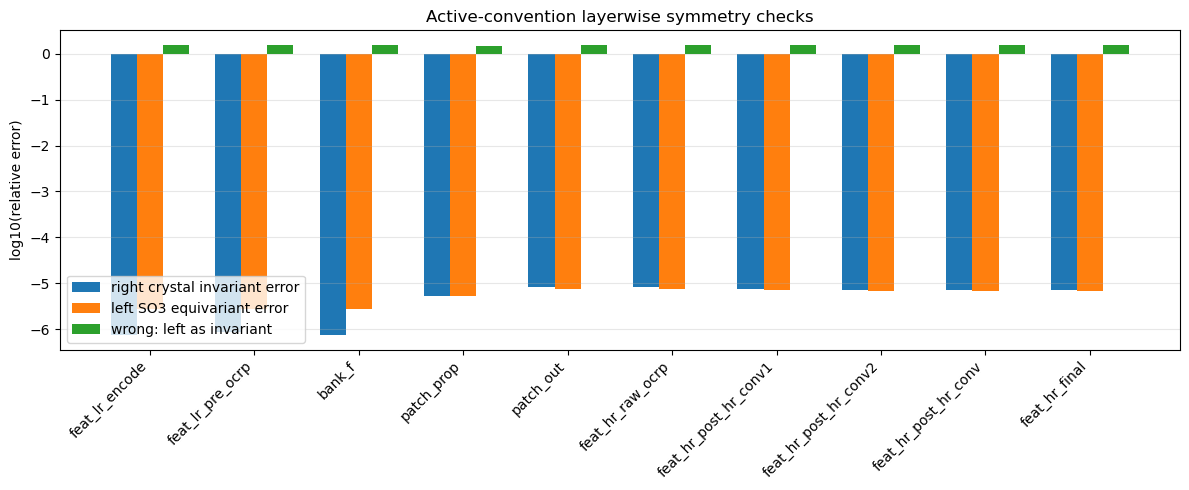

saved: /data/home/umang/Materials/Reynolds-QSR_paper/analysis/out/ocrp_4x4_active_symmetry_layer_proof/layerwise_symmetry_errors.png


In [15]:
import os

os.environ.setdefault("MPLCONFIGDIR", str(OUT_DIR / "mplconfig"))
(OUT_DIR / "mplconfig").mkdir(parents=True, exist_ok=True)

import matplotlib.pyplot as plt

plot_df = df[df["tensor_type"] == "irrep feature"].copy()
plot_df["right_log10"] = np.log10(plot_df["right_rel"].clip(lower=1e-12))
plot_df["left_eq_log10"] = np.log10(plot_df["left_eq_rel"].clip(lower=1e-12))
plot_df["wrong_left_inv_log10"] = np.log10(plot_df["wrong_left_as_invariant_rel"].clip(lower=1e-12))

fig, ax = plt.subplots(figsize=(12, 5))
x = np.arange(len(plot_df))
width = 0.25
ax.bar(x - width, plot_df["right_log10"], width, label="right crystal invariant error")
ax.bar(x, plot_df["left_eq_log10"], width, label="left SO3 equivariant error")
ax.bar(x + width, plot_df["wrong_left_inv_log10"], width, label="wrong: left as invariant")
ax.set_xticks(x)
ax.set_xticklabels(plot_df["tensor"], rotation=45, ha="right")
ax.set_ylabel("log10(relative error)")
ax.set_title("Active-convention layerwise symmetry checks")
ax.legend()
ax.grid(True, axis="y", alpha=0.3)
fig.tight_layout()
plot_path = OUT_DIR / "layerwise_symmetry_errors.png"
fig.savefig(plot_path, dpi=200, bbox_inches="tight")
plt.show()
print("saved:", plot_path)
        

## Final conclusion

For the active-convention OCRP feature pipeline:

1. The local-iso encoder makes the crystal quotient on the **right**:

   $$
   q \sim q\otimes h,\qquad h\in O.
   $$

2. Every irrep-valued feature tensor after that remains:

   $$
   \text{right-crystal invariant}
   \quad\text{and}\quad
   \text{left-SO(3) equivariant}.
   $$

3. Scalar OCRP routing/index tensors are type-0 quantities. The hard routing objects such as `cluster_ids`, `slot_mask`, `slot_meta`, `router_logits`, and `owner_idx` are invariant in the table. The returned `xattn_alpha` diagnostic is scalar too, but shows tiny softmax-level numerical differences; the actual scalar-weighted feature outputs still satisfy the symmetry checks.

4. The side still matters after encoding. Right crystal invariance is inherited by feature-only blocks, but left SO(3) equivariance must be preserved by every operation that touches irrep channels. A generic dense latent projection breaks it; the notebook's counterexample shows this explicitly.

5. There is no magic repeated latent-space projection that fixes symmetry after arbitrary channel mixing. The real projection is the encoder irrep projection; later layers preserve symmetry by construction through equivariant tensor products, scalar invariant routing quantities, and scalar-weighted sums.

6. The wrong-side controls show that this is **not vice versa**:

   - left SO(3) is not an invariance for non-scalar features;
   - right crystal action is not treated as a left \(D(h)\)-equivariance;
   - arbitrary right SO(3) rotations are not crystal invariances.

This is exactly the active-convention behavior:

$$
\boxed{
F(q\otimes h)=F(q),\ h\in O
}
\qquad
\boxed{
F(g\otimes q)=F(q)D(g)^\mathsf{T},\ g\in SO(3)
}
$$

with the transpose appearing only because this implementation stores feature channels as row vectors.
        